In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr, spearmanr

In [65]:
df = pd.read_excel('Новый датасет.xlsx', 0)
df_cl = pd.read_excel('Новый датасет.xlsx', 1)
df_reg = pd.read_excel('Новый датасет.xlsx', 2)

In [66]:
df.isnull().sum()

id_order          0
id_client       588
amt_payment    2144
dtime_pay      2429
dtype: int64

In [67]:
df_d = df[df['id_client'].notnull()]      # Удаление строк с отсутствующим значением уникального идентификатора клиента.

In [68]:
df_d.isnull().sum()

id_order          0
id_client         0
amt_payment    1556
dtime_pay      1841
dtype: int64

In [69]:
df_d = df_d[df_d['dtime_pay'].notnull()] 
# Удаление строк с отсутствующей даты платежа.

In [70]:
df_d.isnull().sum()

id_order       0
id_client      0
amt_payment    0
dtime_pay      0
dtype: int64

In [71]:
df_d.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35560 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     35560 non-null  int64         
 1   id_client    35560 non-null  float64       
 2   amt_payment  35560 non-null  float64       
 3   dtime_pay    35560 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.4 MB


#### В изначальний таблице "Данные" было 37989 записей, осталось после очистки 35560, удалено 2429записей (6.4%).

In [72]:
df_cl.isnull().sum()

id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
dtype: int64

In [73]:
df_cl = df_cl[df_cl['dtime_ad'].notnull()]  
# Удатение строк с отсутствием даты и времеми показа рекламного объявления (если не показана реклама, то невозвожно оценить её влияние на покупку)

In [74]:
df_cl.isnull().sum()

id_client           0
dtime_ad            0
nflag_test          0
id_trading_point    0
dtype: int64

##### В изначальний таблице "Clients" было 55605 записей, осталось после очистки 55356, удалено 249 записей (менее 1 %).

In [75]:
df_reg.isnull().sum()

id_trading_point    0
city                0
dtype: int64

##### Очищенные от NULL значений таблицы из исходного файла Новый диплом датасет.xlsx: Данные - df_d, Clients - df_cl, Region_dict - df_reg

In [76]:
reg_gr = df_reg.groupby('city').agg(cnt_point = ('id_trading_point', 'count')).reset_index()
reg_gr

,city,cnt_point
0,Великий Новгород,1
1,Владимир,1
2,Волгоград,1
3,Дмитров,1
4,Казань,6
5,Краснодар,4
6,Красноярск,5
7,Москва,11
8,Мурманск,2
9,Нижний Новгород,1


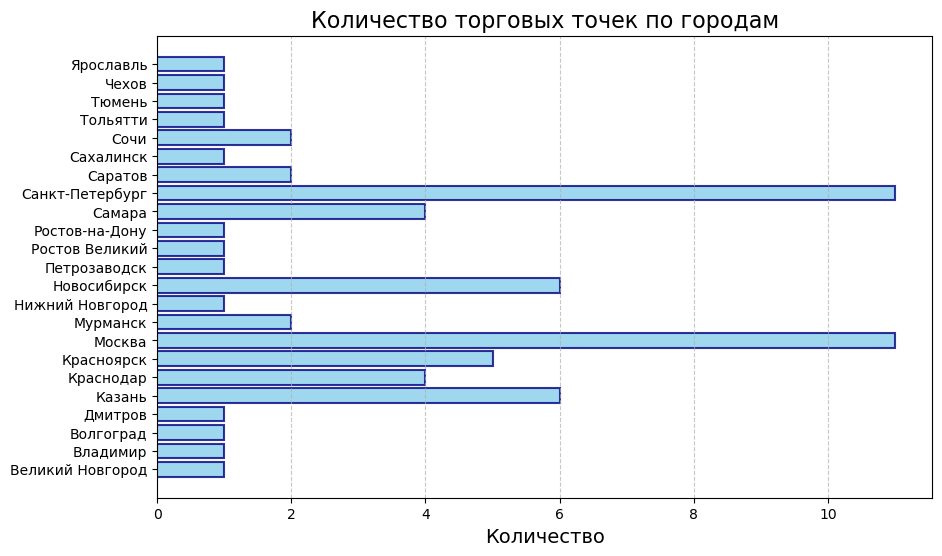

In [77]:
plt.figure(figsize=(10, 6)) 
plt.barh(reg_gr['city'], reg_gr['cnt_point'], color='skyblue',  edgecolor='navy', linewidth=1.5, alpha=0.8)
plt.title('Количество торговых точек по городам', fontsize=16)
plt.xlabel('Количество', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### Наибольшее количество торговых точек находятся в Санкт-Петербурге, Москве, Новосибирске, Казани, Красноярске.

In [78]:
df_d_gr = df_d.groupby('id_client').agg(sum_pay = ('amt_payment', 'sum')).reset_index()
df_d_gr.head()

,id_client,sum_pay
0,178561.0,3052.0
1,178562.0,2439.0
2,178563.0,768.0
3,178565.0,958.0
4,178566.0,5474.0


In [79]:
cl_pay = df_cl.merge(df_d_gr, on='id_client', how='left')   # В таблице остались все клиенты из клиентской таблицы
cl_pay['sum_pay'] = cl_pay['sum_pay'].fillna(0)             # Заполнение нулями сумм покупок тех клиентов, которые покупок не совершали

In [80]:
# Подтягиваем к каждой торговой точке город, в котором она находится
rez = cl_pay.merge(df_reg, on='id_trading_point', how='left')

In [81]:
# Создание поля флаг платежа, который принимает значения 0 или 1 в зависимости от того, заплатил клиент или нет.
rez['flag_pay'] = np.where(rez['sum_pay'] == 0, 0, 1)
rez

,id_client,dtime_ad,nflag_test,id_trading_point,sum_pay,city,flag_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
2,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
3,322530,2022-07-08 08:56:08.714,0,1015,0.0,Краснодар,0
4,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0
...,...,...,...,...,...,...,...
55351,193038,2022-07-09 00:31:25.196,0,1015,5846.0,Краснодар,1
55352,244069,2022-08-08 00:12:31.319,1,991,0.0,Казань,0
55353,189084,2022-06-29 04:34:42.610,1,439,7146.0,Казань,1
55354,182758,2022-06-13 11:28:37.856,1,573,13720.0,Санкт-Петербург,1


In [82]:
# Создаем функцию, которая будет вычислять значение t-критерия (критерия Стьюдента) и p_value для сравнения средних

def test_calc(r1, r2, alpha=0.05):
    print('Разница между средними значениями:', r1.mean()-r2.mean())
    s, p = stats.ttest_ind(r1, r2)
    if p<=alpha:
        print('Гипотеза отвергается, разница статистически значима')
    else:
        print('Гипотеза не отвергается, средние равны')

In [83]:
# Создаем функцию, которая будет рассчитывать значение критерия Манна Уитни и p_value для сравнения распределений

def mann_whitney_func(r1, r2, alpha=0.05):
    U, p = mannwhitneyu(r1, r2)
    if p >= alpha:
        print(f'Принимаем H0 -> нет статистически значимой разницы между выборками. p value = {p}')
    else:
        print(f'Принимаем H1 -> есть статистически значимая разница между выборками. p value = {p}')

In [84]:
no_payments_points = []
unique_points = rez['id_trading_point'].unique()                                       # Получаем уникальные торговые точки
for point in unique_points:
    point_data = rez[rez['id_trading_point'] == point]                                 # Фильтруем данные по торговой точке
    test_group = point_data[point_data['nflag_test'] == 1]                             # Проверяем тестовую группу (nflag_test = 1)
    test_no_payments = (len(test_group) > 0) and (test_group['sum_pay'].sum() == 0)
    control_group = point_data[point_data['nflag_test'] == 0]                          # Проверяем контрольную группу (nflag_test = 0)
    control_no_payments = (len(control_group) > 0) and (control_group['sum_pay'].sum() == 0)
    if test_no_payments or control_no_payments:                                        # Если в тестовой ИЛИ контрольной группе не было платежей
        no_payments_points.append(point)
print(f"Торговые точки без платежей в тестовой или контрольной группе: {no_payments_points}")

Торговые точки без платежей в тестовой или контрольной группе: [np.int64(46), np.int64(26), np.int64(7), np.int64(23), np.int64(4), np.int64(1), np.int64(13)]


In [85]:
missing_group_points = []
for point in unique_points:
    point_data = rez[rez['id_trading_point'] == point]
    has_test = (point_data['nflag_test'] == 1).any()                             # Проверяем наличие тестовой группы
    has_control = (point_data['nflag_test'] == 0).any()                          # Проверяем наличие контрольной группы
    if (has_test and not has_control) or (not has_test and has_control):         # Если отсутствует или тестовая, или контрольная группа
        missing_group_points.append(point)
print(f"Торговые точки с отсутствующей тестовой или контрольной группой: {missing_group_points}")

Торговые точки с отсутствующей тестовой или контрольной группой: [np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(228), np.int64(603), np.int64(810), np.int64(800)]


In [86]:
# Отбросим все торговые точки из списков 'no_payments_points' и 'missing_group_points'.
rez_och = rez[(~rez['id_trading_point'].isin(no_payments_points))&(~rez['id_trading_point'].isin(missing_group_points))]
rez_och

,id_client,dtime_ad,nflag_test,id_trading_point,sum_pay,city,flag_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
2,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
4,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0
5,195818,2022-07-16 01:30:59.088,1,2652,4021.0,Москва,1
...,...,...,...,...,...,...,...
55350,188702,2022-06-28 06:16:25.664,0,453,1323.0,Санкт-Петербург,1
55352,244069,2022-08-08 00:12:31.319,1,991,0.0,Казань,0
55353,189084,2022-06-29 04:34:42.610,1,439,7146.0,Казань,1
55354,182758,2022-06-13 11:28:37.856,1,573,13720.0,Санкт-Петербург,1


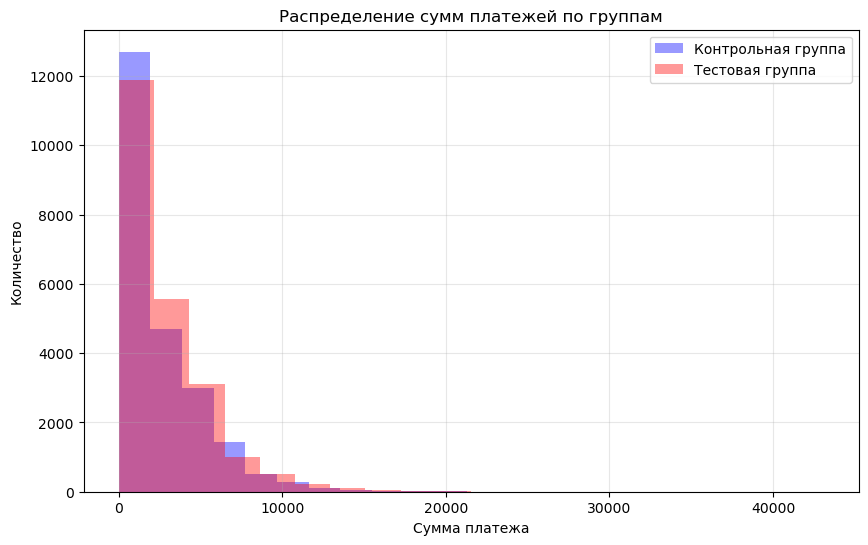

In [87]:
plt.figure(figsize=(10, 6))
control_data = rez_och[rez_och['nflag_test'] == 0]['sum_pay']
plt.hist(control_data, bins=20, alpha=0.4, label='Контрольная группа', color='blue', density=False)
test_data = rez_och[rez_och['nflag_test'] == 1]['sum_pay']
plt.hist(test_data, bins=20, alpha=0.4, label='Тестовая группа', color='red', density=False)

plt.xlabel('Сумма платежа')
plt.ylabel('Количество')
plt.title('Распределение сумм платежей по группам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [88]:
rez_test = rez_och[rez_och['nflag_test']==1]
rez_control = rez_och[rez_och['nflag_test']==0]

In [89]:
print('Количество наблюдений')
print('В тестовой группе ', rez_test['id_client'].count())
print('В контрольной группе', rez_control['id_client'].count())

Количество наблюдений
В тестовой группе  22445
В контрольной группе 22873


#### Размеры групп сопоставимы. 

In [90]:
print('Средний чек')
print('В тестовой группе ', rez_test['sum_pay'].mean())
print('В контрольной группе', rez_control['sum_pay'].mean())
print('Конверсии')
print('В тестовой группе ',rez_test['flag_pay'].mean())
print('В контрольной группе', rez_control['flag_pay'].mean())

Средний чек
В тестовой группе  2452.2773446201827
В контрольной группе 2189.1884317754557
Конверсии
В тестовой группе  0.5432835820895522
В контрольной группе 0.49975954181786386


##### Мы видим, что конверсия в тестовой группе оказалась примерно на 5 процентных пунктов выше, чем у контрольной группы. 
##### Также мы видим, что средний чек в тестовой группе увеличился. 
##### Является ли эта разница статистически значимой выясним, когда проведём подсчет A/B тестов.

Применяем функцию test_calc и сравниваем средние платежи.

In [91]:
test_calc(rez_test['sum_pay'], rez_control['sum_pay'], alpha=0.05)

Разница между средними значениями: 263.088912844727
Гипотеза отвергается, разница статистически значима


Применяем функцию test_calc и сравниваем конверсию в платеж.

In [92]:
test_calc(rez_test['flag_pay'], rez_control['flag_pay'], alpha=0.05)

Разница между средними значениями: 0.043524040271688325
Гипотеза отвергается, разница статистически значима


##### Анализируя результаты теста средних платежей приходим к выводу что платежи не равны.
##### Анализируя результаты теста конверсии в платёж приходим к выводу что конверсии не равны.
#### В тестовой группе выросла конверсия в покупку и средний чек.

In [93]:
# Применяем функцию mann_whitney_func на средних платежах.
mann_whitney_func(rez_test['sum_pay'], rez_control['sum_pay'])

Принимаем H1 -> есть статистически значимая разница между выборками. p value = 3.008345273971901e-24


In [94]:
# Применяем функцию mann_whitney_func на конверсии в покупку.
mann_whitney_func(rez_test['flag_pay'], rez_control['flag_pay'])

Принимаем H1 -> есть статистически значимая разница между выборками. p value = 1.8043406994299902e-20


##### Тесты для расчета критерия Манна Уитнии и p_value для сравнения распределений и среди средних платежей, и конверсии в покупку приводят к выводу о том, что разница в контрольной и тестовой группах статичтически значима.

In [95]:
rez_test_M = rez_och[(rez_och['nflag_test']==1)&(rez_och['city']=='Москва')]
rez_control_M = rez_och[(rez_och['nflag_test']==0)&(rez_och['city']=='Москва')]
rez_test_S = rez_och[(rez_och['nflag_test']==1)&(rez_och['city']=='Санкт-Петербург')]
rez_control_S = rez_och[(rez_och['nflag_test']==0)&(rez_och['city']=='Санкт-Петербург')]
rez_test_O = rez_och[(rez_och['nflag_test']==1)&(rez_och['city']!='Москва')&(rez_och['city']!='Санкт-Петербург')]
rez_control_O = rez_och[(rez_och['nflag_test']==0)&(rez_och['city']!='Москва')&(rez_och['city']!='Санкт-Петербург')]

Проведём аналитику в отношении Москвы.

In [96]:
test_calc(rez_test_M['sum_pay'], rez_control_M['sum_pay'], alpha=0.05)

Разница между средними значениями: 381.7784892750842
Гипотеза отвергается, разница статистически значима


In [97]:
test_calc(rez_test_M['flag_pay'], rez_control_M['flag_pay'], alpha=0.05)

Разница между средними значениями: 0.05557800593933432
Гипотеза отвергается, разница статистически значима


In [98]:
mann_whitney_func(rez_test_M['sum_pay'], rez_control_M['sum_pay'])

Принимаем H1 -> есть статистически значимая разница между выборками. p value = 7.010591402203484e-16


In [99]:
mann_whitney_func(rez_test_M['flag_pay'], rez_control_M['flag_pay'])

Принимаем H1 -> есть статистически значимая разница между выборками. p value = 6.370381156613038e-10


#### В тестовой группе в Москве выросла и конверсия в покупку и средний чек.

Проведём аналитику в отношении Санкт-Петербурга.

In [100]:
test_calc(rez_test_M['sum_pay'], rez_control_M['sum_pay'], alpha=0.05)

Разница между средними значениями: 381.7784892750842
Гипотеза отвергается, разница статистически значима


In [101]:
test_calc(rez_test_M['flag_pay'], rez_control_M['flag_pay'], alpha=0.05)

Разница между средними значениями: 0.05557800593933432
Гипотеза отвергается, разница статистически значима


In [102]:
mann_whitney_func(rez_test_M['sum_pay'], rez_control_M['sum_pay'])

Принимаем H1 -> есть статистически значимая разница между выборками. p value = 7.010591402203484e-16


In [103]:
mann_whitney_func(rez_test_M['flag_pay'], rez_control_M['flag_pay'])

Принимаем H1 -> есть статистически значимая разница между выборками. p value = 6.370381156613038e-10


#### В тестовой группе в Санкт-Петербурге выросла и конверсия в покупку и средний чек.

Проведём аналитику по оставшимся городам.

In [104]:
rez_O = rez_och[(rez_och['city']!='Москва')&(rez_och['city']!='Санкт-Петербург')]
unique_points = rez_O['city'].unique()
for i in unique_points:
    print (i)
    rez_test_O = rez_O[(rez_O['nflag_test']==1)&(rez_O['city']==i)]
    rez_control_O = rez_O[(rez_O['nflag_test']==0)&(rez_O['city']==i)]
    print('Результат вычисления значения t-критерия (критерия Стьюдента) и p_value для средних платежей')
    test_calc(rez_test_O['sum_pay'], rez_control_O['sum_pay'], alpha=0.05)
    print('Результат вычисления значения t-критерия (критерия Стьюдента) и p_value для конверсии в платёж')
    test_calc(rez_test_O['flag_pay'], rez_control_O['flag_pay'], alpha=0.05)
    print('Результат теста для расчета критерия Манна Уитнии и p_value для средних платежей')
    mann_whitney_func(rez_test_O['sum_pay'], rez_control_O['sum_pay'])
    print('Результат теста для расчета критерия Манна Уитнии и p_valueдля конверсии в платёж')
    mann_whitney_func(rez_test_O['flag_pay'], rez_control_O['flag_pay'])
    print()

Красноярск
Результат вычисления значения t-критерия (критерия Стьюдента) и p_value для средних платежей
Разница между средними значениями: 8.718297889251062
Гипотеза не отвергается, средние равны
Результат вычисления значения t-критерия (критерия Стьюдента) и p_value для конверсии в платёж
Разница между средними значениями: -0.003592020255924089
Гипотеза не отвергается, средние равны
Результат теста для расчета критерия Манна Уитнии и p_value для средних платежей
Принимаем H0 -> нет статистически значимой разницы между выборками. p value = 0.8770469886251647
Результат теста для расчета критерия Манна Уитнии и p_valueдля конверсии в платёж
Принимаем H0 -> нет статистически значимой разницы между выборками. p value = 0.7805140863923713

Мурманск
Результат вычисления значения t-критерия (критерия Стьюдента) и p_value для средних платежей
Разница между средними значениями: 8.051371737534055
Гипотеза не отвергается, средние равны
Результат вычисления значения t-критерия (критерия Стьюдента)

Средний чек и конверсия в покупку в контрольной и тестовой группах равны: Красноярск, 
Мурманск, Казань, Саратов, Тольятти, Волгоград, Краснодар, Сахалинск, Дмитров.

Тюмень - значения t-критерия (критерия Стьюдента) и p_value указывают на то, что средние платежи равны, в расчете критерия Манна Уитнии и p_value есть статистически значимая разница между выборками. Конверсии не равны

Сочи - средние чеки в контрольной и тестовой группах равны, конверсия в покупку не равны.

Владимир - конверсии в покупку равны, средние чеки не равны.

Самара - в тестовой группе выросла и конверсия в покупку, и средний чек.

#### Общий вывод: Москва, Санкт-Петербург, Самара и Владимир "оттянули" к своим возросшим показателями результаты всей сети, хотя во всех остальных городах статистически значимых изменений не наблюдается.

In [106]:
rez_och.head()

,id_client,dtime_ad,nflag_test,id_trading_point,sum_pay,city,flag_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
2,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
4,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0
5,195818,2022-07-16 01:30:59.088,1,2652,4021.0,Москва,1


In [107]:
def test_calc2(r1, r2, alpha=0.05):
    diff = r1.mean()-r2.mean()                     # Разница между средними значениями
    ttest, pvalue_ttest = stats.ttest_ind(r1, r2)  # значение статистического критерия и pvalue статистического критерия
    return diff, ttest, pvalue_ttest

In [108]:
results = []

for (city, point), group in rez_och.groupby(['city', 'id_trading_point']):
    test = group[group['nflag_test'] == 1]
    control = group[group['nflag_test'] == 0]
    if len(test) > 0 and len(control) > 0:
        avg_payment_test = test['sum_pay'].mean()
        avg_payment_control = control['sum_pay'].mean()
        sigma_test = test['sum_pay'].std()
        sigma_control = control['sum_pay'].std()
        count_test = len(test)
        count_control = len(control)
        count_all = count_test + count_control
        percent_count = (count_all / len(rez_och))*100
        diff, ttest, pvalue_ttest = test_calc2(test['sum_pay'], control['sum_pay'], alpha=0.05)
        if pvalue_ttest < 0.05:  
            if diff > 0:
                flag = 1  
            elif diff < 0:
                flag = -1  
            else:
                flag = 0   
        else: 
            flag = 0  
        results.append({
            'city': city,
            'id_trading_point': point,
            'count_test': count_test,
            'count_control': count_control,
            'count_all': count_all,
            'percent_count': percent_count,
            'avg_payment_test': avg_payment_test,
            'avg_payment_control': avg_payment_control,
            'diff' : diff,
            'sigma_test' : sigma_test,
            'sigma_control' : sigma_control,
            'ttest' : ttest,
            'pvalue_ttest': pvalue_ttest,
            'flag' : flag
        })

results_df = pd.DataFrame(results)  

In [109]:
results_df

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,flag
0,Владимир,11,509,608,1117,2.464804,2547.220039,2108.610197,438.609842,3023.702164,2663.038392,2.576955,1.009511e-02,1
1,Волгоград,66,657,703,1360,3.001015,2288.870624,2601.761024,-312.890400,2682.567610,2830.193773,-2.089272,3.686900e-02,-1
2,Дмитров,2,78,71,149,0.328788,579.333333,483.450704,95.882629,1860.762430,1654.923182,0.331052,7.410763e-01,0
3,Казань,439,355,351,706,1.557880,2481.960563,2400.635328,81.325236,4040.441007,3722.117072,0.278067,7.810423e-01,0
4,Казань,477,382,386,768,1.694691,2259.623037,2496.987047,-237.364010,3482.846094,3881.994719,-0.891593,3.728909e-01,0
5,Казань,516,634,636,1270,2.802418,3237.200315,2880.484277,356.716039,4537.103842,3819.292813,1.515887,1.297971e-01,0
6,Казань,544,377,416,793,1.749857,2621.427056,2635.548077,-14.121021,3714.894751,4639.820746,-0.046997,9.625274e-01,0
7,Казань,699,482,494,976,2.153670,2422.286307,2574.352227,-152.065920,3906.817897,4082.851356,-0.594254,5.524804e-01,0
8,Казань,991,270,294,564,1.244539,3249.281481,2452.986395,796.295087,4719.592601,3633.935858,2.255258,2.450100e-02,1
9,Краснодар,1101,785,869,1654,3.649764,2176.003822,2523.578826,-347.575005,2722.624494,2960.352338,-2.476736,1.335845e-02,-1


In [110]:
positive_df = results_df[results_df['flag'] == 1].copy()
negative_df = results_df[results_df['flag'] == -1].copy()
neutral_df = results_df[results_df['flag'] == 0].copy()
with pd.ExcelWriter('Результаты_эксперимента.xlsx', engine='openpyxl') as writer:
    positive_df.to_excel(writer, sheet_name='Положительные', index=False)
    negative_df.to_excel(writer, sheet_name='Отрицательные', index=False)
    neutral_df.to_excel(writer, sheet_name='Нейтральные', index=False)
    results_df.to_excel(writer, sheet_name='Все_результаты', index=False)